In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
type1_df = pd.read_csv('/Users/jisoyun/Desktop/sparta_python/심화 프로젝트/hotsix/data/df_clean_Type1.csv')
type1_df.columns = type1_df.columns.str.strip()

In [2]:
#---------------------
# 1. 정규성 검정
#---------------------
from scipy import stats

target_vars = [
    'Factory_Humidity', 'Factory_Temp', 'Spray_Time',
    'Biscuit_Thickness', 'Pressure_Diff', 'Pressure_Rise_Time',
    'Air_Pressure', 'Clamping_Force', 'Coolant_Pressure', 'High_Velocity'
]

results = []
for col in target_vars:
    stat, p = stats.shapiro(type1_df[col].dropna())
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': round(p, 4),
        '정규성': '✅' if p > 0.05 else '❌'
    })

print(pd.DataFrame(results).to_string(index=False))

                변수   W통계량  p-value 정규성
  Factory_Humidity 0.9064      0.0   ❌
      Factory_Temp 0.8753      0.0   ❌
        Spray_Time 0.8200      0.0   ❌
 Biscuit_Thickness 0.8671      0.0   ❌
     Pressure_Diff 0.8253      0.0   ❌
Pressure_Rise_Time 0.7748      0.0   ❌
      Air_Pressure 0.9485      0.0   ❌
    Clamping_Force 0.9369      0.0   ❌
  Coolant_Pressure 0.9184      0.0   ❌
     High_Velocity 0.9834      0.0   ❌


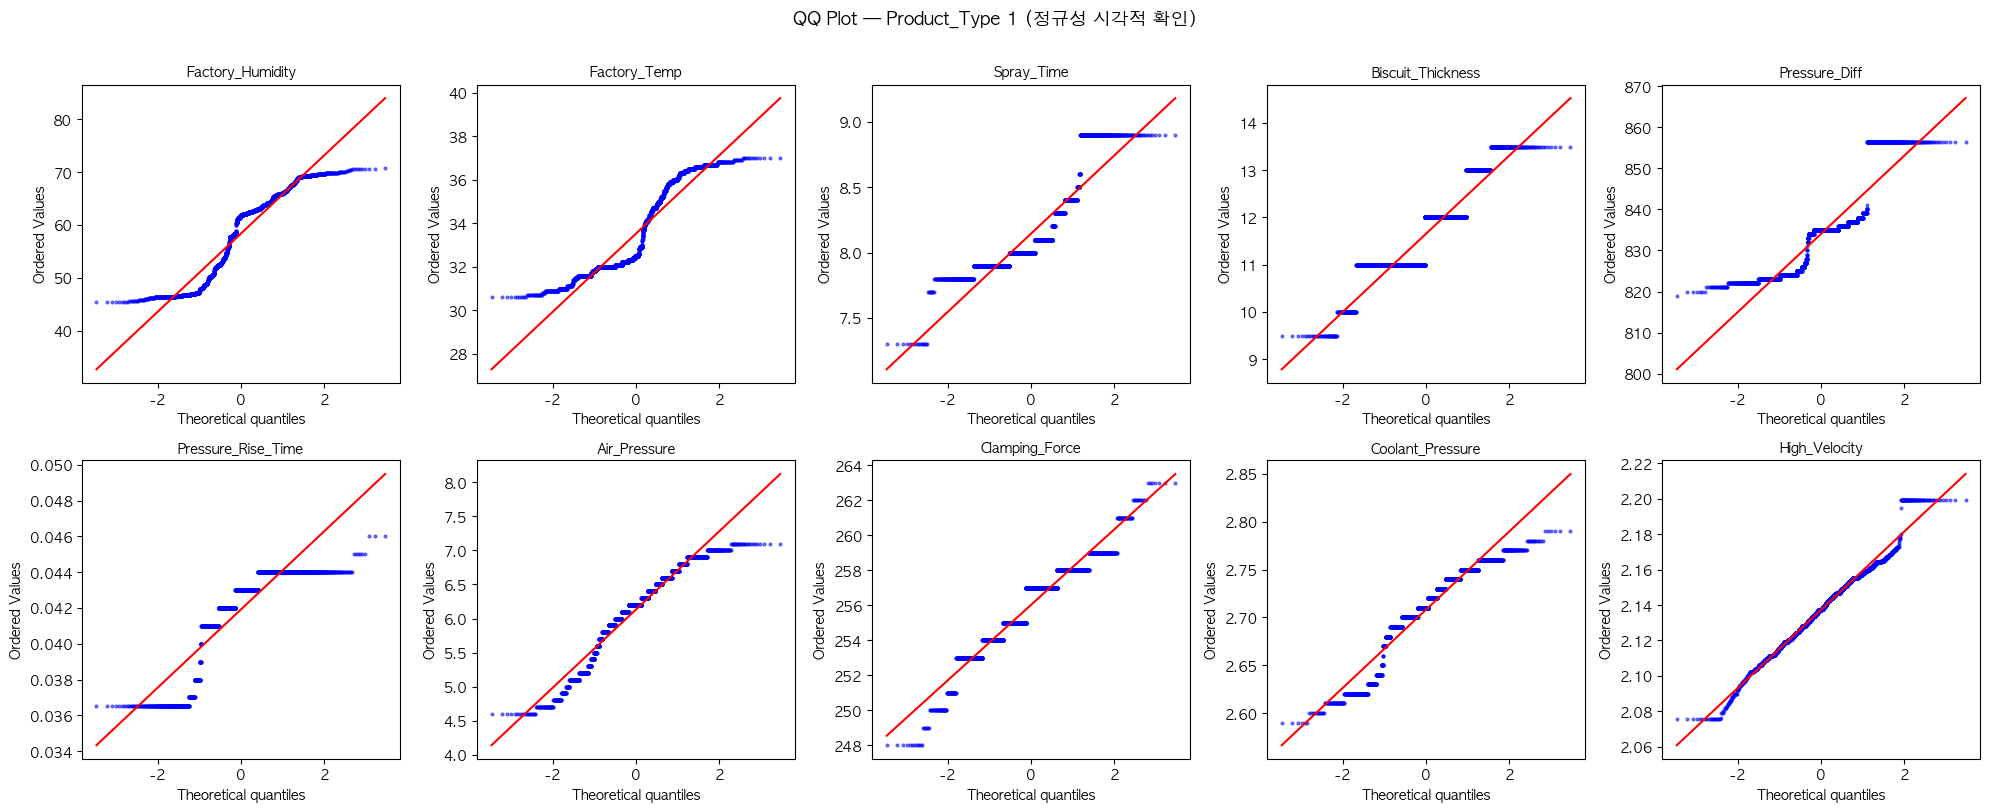

In [3]:
#---------------------
# 1-2. QQ Plot
#---------------------

import scipy.stats as stats
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(target_vars):
    stats.probplot(type1_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

plt.suptitle('QQ Plot — Product_Type 1 (정규성 시각적 확인)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [4]:
#---------------------
# 2. Mann-Whitney U 검정
#---------------------

from scipy.stats import mannwhitneyu

defect   = type1_df[type1_df['Defect_Status'] == 1]
normal   = type1_df[type1_df['Defect_Status'] == 0]

results = []
for col in target_vars:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
print(result_df.to_string(index=False))

                변수     U통계량  p-value 유의성
  Factory_Humidity 364863.5   0.0000   ✅
      Factory_Temp 777645.0   0.0000   ✅
        Spray_Time 518244.0   0.0000   ✅
 Biscuit_Thickness 464880.0   0.0000   ✅
     Pressure_Diff 491771.5   0.0000   ✅
Pressure_Rise_Time 678184.5   0.0000   ✅
    Clamping_Force 662918.5   0.0000   ✅
      Air_Pressure 658564.5   0.0002   ✅
     High_Velocity 658198.5   0.0002   ✅
  Coolant_Pressure 562304.0   0.0292   ✅


In [5]:
#---------------------
# 3. 효과크기 계산 (Rank-Biserial Correlation)
#---------------------

from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

defect = type1_df[type1_df['Defect_Status'] == 1]
normal = type1_df[type1_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in target_vars:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
print(result_df.to_string(index=False))

                변수  p-value  효과크기(r) 해석
  Factory_Humidity   0.0000   0.3895  중
      Factory_Temp   0.0000   0.3013  중
 Biscuit_Thickness   0.0000   0.2221  소
     Pressure_Diff   0.0000   0.1771  소
Pressure_Rise_Time   0.0000   0.1348  소
        Spray_Time   0.0000   0.1328  소
    Clamping_Force   0.0000   0.1093  소
      Air_Pressure   0.0002   0.1020  소
     High_Velocity   0.0002   0.1014  소
  Coolant_Pressure   0.0292   0.0591  소


In [6]:
#---------------------
# 4. Kruskal-Wallis H 검정 (Defect_Type별 차이
#---------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']

results = []
for col in target_vars:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
print(result_df.to_string(index=False))

                변수   H통계량  p-value 유의성
  Factory_Humidity 273.35   0.0000   ✅
      Factory_Temp 221.14   0.0000   ✅
        Spray_Time  34.69   0.0000   ✅
 Biscuit_Thickness  76.29   0.0000   ✅
     Pressure_Diff  45.42   0.0000   ✅
Pressure_Rise_Time  29.81   0.0000   ✅
  Coolant_Pressure  45.27   0.0000   ✅
     High_Velocity  22.03   0.0002   ✅
    Clamping_Force  20.38   0.0004   ✅
      Air_Pressure  16.35   0.0026   ✅


In [7]:
#---------------------
# 5. 효과크기 계산 (Epsilon-squared)
#---------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']
n_total = len(type1_df)

results = []
for col in target_vars:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    
    # epsilon-squared = H / (n - 1) / (n + 1) * n
    eps_sq = stat / (n_total - 1)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        'ε²': round(eps_sq, 4),
        '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
    })

result_df = pd.DataFrame(results).sort_values('ε²', ascending=False)
print(result_df.to_string(index=False))

                변수   H통계량  p-value     ε² 해석
  Factory_Humidity 273.35   0.0000 0.1032  중
      Factory_Temp 221.14   0.0000 0.0834  중
 Biscuit_Thickness  76.29   0.0000 0.0288  소
     Pressure_Diff  45.42   0.0000 0.0171  소
  Coolant_Pressure  45.27   0.0000 0.0171  소
        Spray_Time  34.69   0.0000 0.0131  소
Pressure_Rise_Time  29.81   0.0000 0.0112  소
     High_Velocity  22.03   0.0002 0.0083  소
    Clamping_Force  20.38   0.0004 0.0077  소
      Air_Pressure  16.35   0.0026 0.0062  소
